#Importing Dataset from Kaggle

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("grassknoted/asl-alphabet")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'asl-alphabet' dataset.
Path to dataset files: /kaggle/input/asl-alphabet


In [ ]:
import os

print(os.listdir("/kaggle/input/asl-alphabet"))

['asl_alphabet_test', 'asl_alphabet_train']


In [ ]:
DATASET_PATH = "/kaggle/input/asl-alphabet"

TRAIN_PATH = os.path.join(
    DATASET_PATH,
    "asl_alphabet_train",
    "asl_alphabet_train"
)

TEST_PATH = os.path.join(
    DATASET_PATH,
    "asl_alphabet_test",
    "asl_alphabet_test"
)

print(TRAIN_PATH)
print(TEST_PATH)

/kaggle/input/asl-alphabet/asl_alphabet_train/asl_alphabet_train
/kaggle/input/asl-alphabet/asl_alphabet_test/asl_alphabet_test


In [ ]:
classes = sorted(os.listdir(TRAIN_PATH))

print("Number of classes:", len(classes))
print(classes)

Number of classes: 29
['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']


In [ ]:
from PIL import Image

sample_class = "A"

img_path = os.path.join(
    TRAIN_PATH,
    sample_class,
    os.listdir(os.path.join(TRAIN_PATH, sample_class))[0]
)

img = Image.open(img_path)

print("Size:", img.size)
print("Mode:", img.mode)

Size: (200, 200)
Mode: RGB


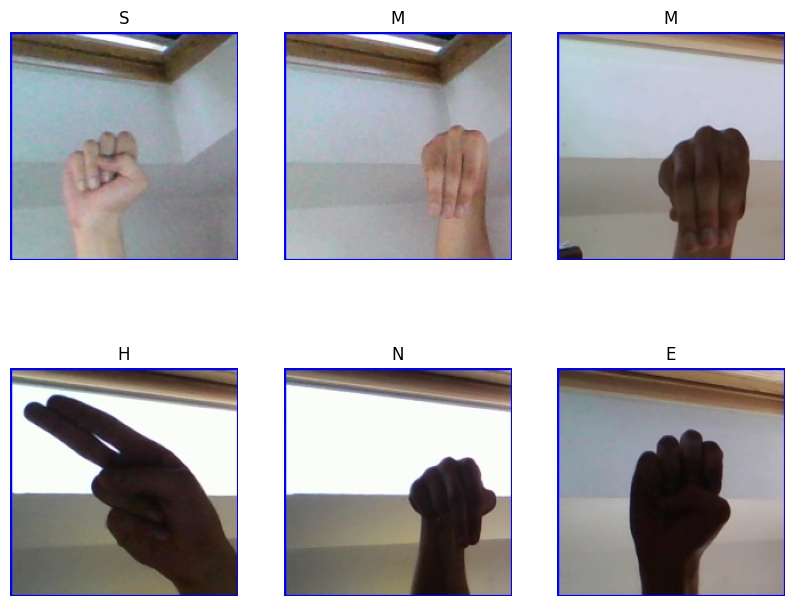

In [ ]:
import random
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(2, 3, figsize=(10, 8))

for ax in axes.flatten():

    cls = random.choice(classes)

    img_name = random.choice(
        os.listdir(os.path.join(TRAIN_PATH, cls))
    )

    img_path = os.path.join(
        TRAIN_PATH,
        cls,
        img_name
    )

    img = Image.open(img_path)

    ax.imshow(img)
    ax.set_title(cls)
    ax.axis("off")

plt.show()

In [ ]:
for cls in classes[:29]:
    count = len(os.listdir(os.path.join(TRAIN_PATH, cls)))
    print(cls, count)

A 3000
B 3000
C 3000
D 3000
E 3000


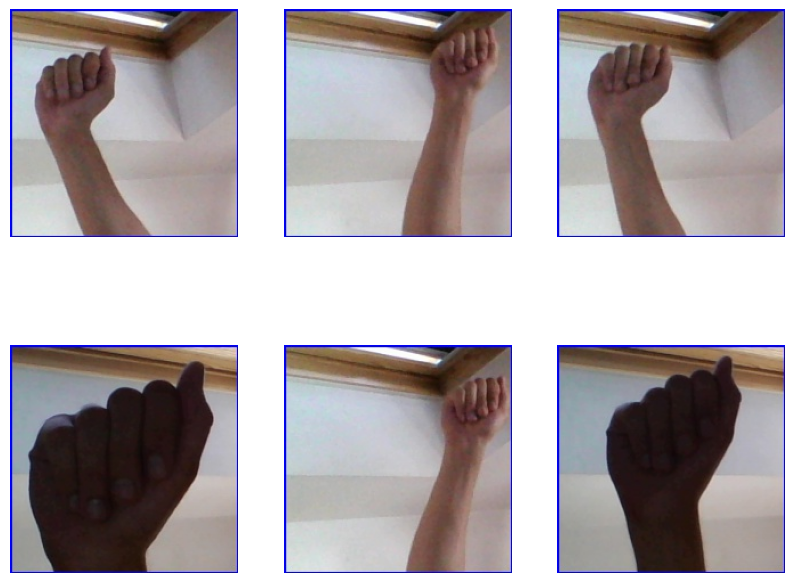

In [ ]:
cls = "A"

images = random.sample(
    os.listdir(os.path.join(TRAIN_PATH, cls)),
    6
)

fig, axes = plt.subplots(2, 3, figsize=(10, 8))

for ax, img_name in zip(axes.flatten(), images):

    img_path = os.path.join(
        TRAIN_PATH,
        cls,
        img_name
    )

    img = Image.open(img_path)

    ax.imshow(img)
    ax.axis("off")

plt.show()

In [ ]:
total = 0

for cls in classes:
    total += len(
        os.listdir(
            os.path.join(TRAIN_PATH, cls)
        )
    )

print(total)

87000


In [ ]:
from torchvision import datasets
from sklearn.model_selection import train_test_split

In [ ]:
dataset = datasets.ImageFolder(TRAIN_PATH)

print(len(dataset))

87000


In [ ]:
from torchvision import datasets
from sklearn.model_selection import train_test_split

dataset = datasets.ImageFolder(TRAIN_PATH)

indices = list(range(len(dataset)))

train_idx, temp_idx = train_test_split(
    indices,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.5,
    random_state=42,
    shuffle=True
)

print("Train:", len(train_idx))
print("Validation:", len(val_idx))
print("Test:", len(test_idx))

Train: 69600
Validation: 8700
Test: 8700


#Data Augmentation

In [ ]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.RandomRotation(10),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
from torchvision import datasets

train_full_dataset = datasets.ImageFolder(
    TRAIN_PATH,
    transform=train_transform
)

eval_full_dataset = datasets.ImageFolder(
    TRAIN_PATH,
    transform=eval_transform
)

In [ ]:
print(len(train_idx))
print(len(val_idx))
print(len(test_idx))

69600
8700
8700


In [ ]:
from torch.utils.data import Subset

train_dataset = Subset(
    train_full_dataset,
    train_idx
)

val_dataset = Subset(
    eval_full_dataset,
    val_idx
)

test_dataset = Subset(
    eval_full_dataset,
    test_idx
)

In [ ]:
print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))

69600
8700
8700


In [ ]:
image, label = train_dataset[0]

print(image.shape)
print(label)

torch.Size([3, 224, 224])
23


In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2
)

In [ ]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([64, 3, 224, 224])
torch.Size([64])


In [ ]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

cuda


In [ ]:
weights = models.EfficientNet_B0_Weights.DEFAULT

model = models.efficientnet_b0(
    weights=weights
)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 153MB/s]


In [ ]:
model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    29
)

In [ ]:
model = model.to(device)

In [ ]:
print(model.classifier)

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=29, bias=True)
)


In [ ]:
import torch.nn as nn

criterion = nn.CrossEntropyLoss()

In [ ]:
import torch.optim as optim

optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

In [ ]:
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

In [ ]:
print(criterion)
print(type(optimizer).__name__)

CrossEntropyLoss()
AdamW


#Training Loop

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = outputs.max(1)

        total += labels.size(0)

        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = 100.0 * correct / total

    return epoch_loss, epoch_acc

#Computing Accuracy

In [ ]:
def evaluate(model, loader, criterion, device):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            running_loss += loss.item() * images.size(0)

            _, predicted = outputs.max(1)

            total += labels.size(0)

            correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = 100.0 * correct / total

    return epoch_loss, epoch_acc

In [ ]:
len(train_loader)
len(val_loader)

136

In [ ]:
print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 1088
Val batches: 136
Test batches: 136


In [ ]:
len(os.listdir(TEST_PATH))

28

In [ ]:
print(len(train_idx))
print(len(val_idx))

overlap = set(train_idx).intersection(set(val_idx))

print("Overlap:", len(overlap))

69600
8700
Overlap: 0


In [ ]:
num_epochs = 10

for epoch in range(num_epochs):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc = evaluate(
        model,
        val_loader,
        criterion,
        device
    )

    scheduler.step(val_loss)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.2f}%"
    )

Epoch [1/10] | Train Loss: 0.0174 | Train Acc: 99.73% | Val Loss: 0.0015 | Val Acc: 99.97%
Epoch [2/10] | Train Loss: 0.0064 | Train Acc: 99.86% | Val Loss: 0.0003 | Val Acc: 100.00%


KeyboardInterrupt: 

### Training Note

Training was stopped early after achieving near-perfect validation accuracy. The dataset contains highly homogeneous samples, making additional epochs unlikely to improve practical performance. Focus was instead shifted to real-world evaluation using webcam input and MediaPipe-based hand detection.


#Saving the model and classes.json file

In [ ]:
torch.save(
    model.state_dict(),
    "asl_efficientnet_b0.pth"
)

In [ ]:
import json

with open("classes.json", "w") as f:
    json.dump(
        train_full_dataset.classes,
        f
    )

## Conclusion

In this project, an EfficientNet-B0 model was trained on the ASL Alphabet dataset and integrated with MediaPipe hand tracking to build a real-time American Sign Language recognition system. The final pipeline successfully performs hand detection, preprocessing, and gesture classification directly from webcam input.

While the dataset achieved very high validation accuracy, real-world testing through webcam inference provided a more practical measure of performance. Future improvements include collecting more diverse training data and extending the system to sentence-level sign language recognition.
